# Buscar Scores vs Cell Count Scatter Plot (Healthy TGFRi)

This notebook plots the relationship between Buscar scores and cell counts for healthy TGFRi replicates.

In [1]:
library(ggplot2)
library(dplyr)
library(ggpubr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


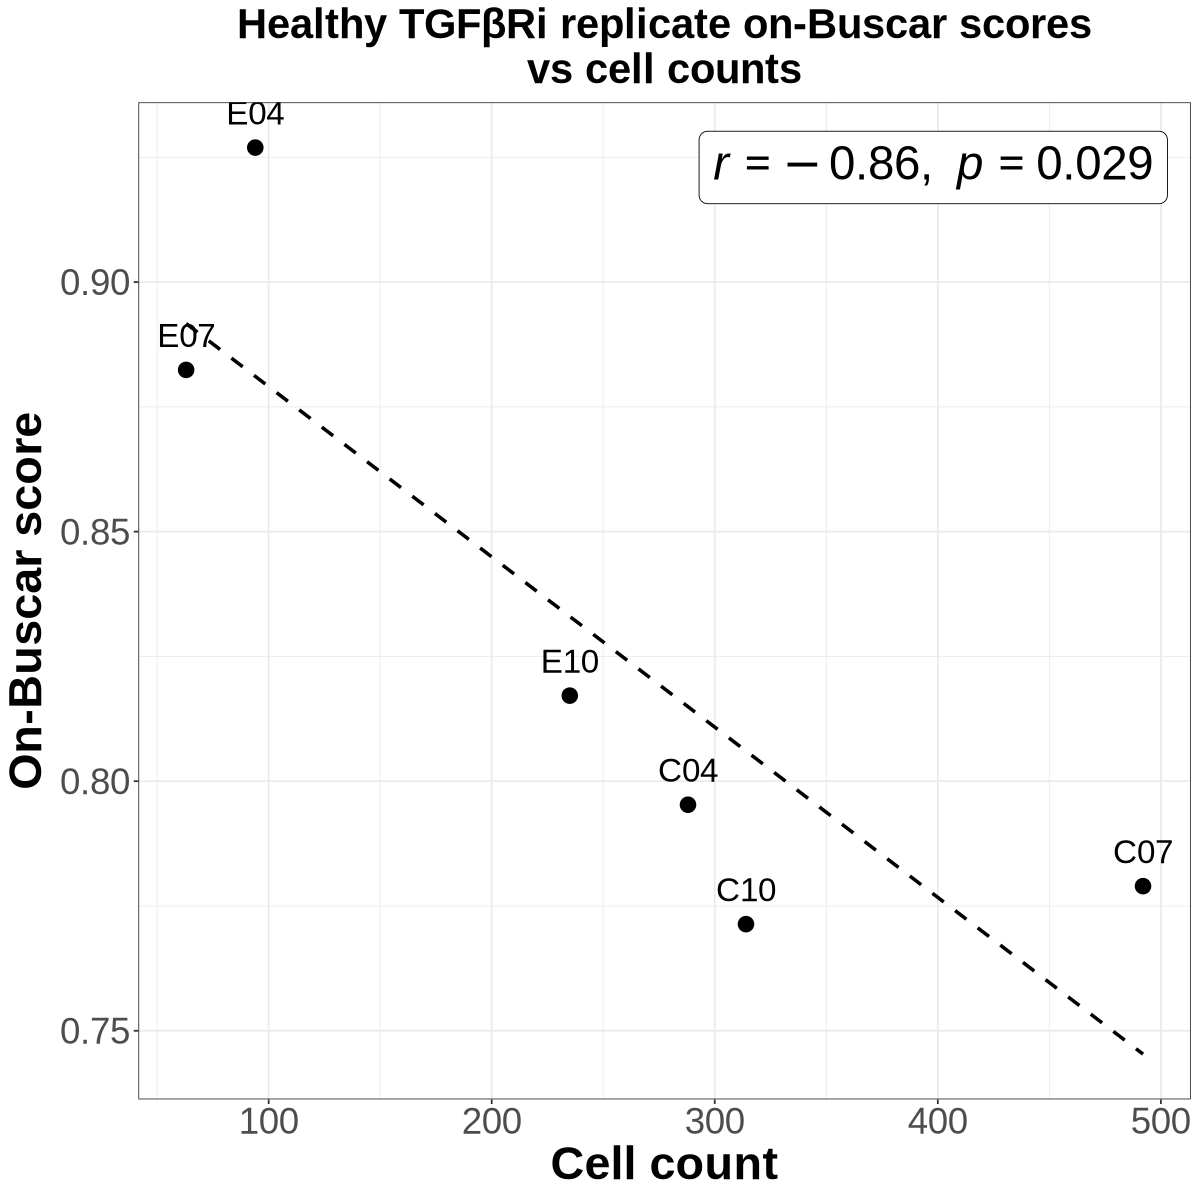

In [2]:
width <- 10
height <- 10
options(repr.plot.width = width, repr.plot.height = height)
# Load data
scores_path <- "../results/phenotypic_scores/cellpainting_cardiac_fibrosis_buscar_scores_replicates.csv"
df <- read.csv(scores_path)

# Filter for healthy TGFRi
df_filtered <- df %>%
  filter(treatment == "healthy-TGFRi")

# Compute Pearson correlation label with explicit statistical notation
on_cor <- cor.test(df_filtered$cell_counts, df_filtered$on_buscar_scores, method = "pearson")
on_label <- sprintf(
  "italic(r) == %.2f*','~~italic(p) == %.3f",
  unname(on_cor$estimate),
  on_cor$p.value
)

# Use on_buscar_scores column
# Create plot
p <- ggplot(df_filtered, aes(x = cell_counts, y = on_buscar_scores)) +
  geom_point(size = 4) +
  geom_text(aes(label = well), vjust = -1, size = 7) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linetype = "dashed") +
  annotate(
    "label",
    x = Inf, y = Inf,
    label = on_label,
    parse = TRUE,
    hjust = 1.05, vjust = 1.4,
    size = 10,
    fill = "white"
  ) +
  labs(
    title = "Healthy TGFβRi replicate on-Buscar scores\nvs cell counts",
    x = "Cell count",
    y = "On-Buscar score"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 25, face = "bold"),
    axis.title = element_text(size = 28, face = "bold"),
    axis.text = element_text(size = 22),
    legend.position = "none"
  )

# Save plot
ggsave("figures/healthy_tgfri_on_buscar_vs_cell_count.png", p, width = width, height = height, dpi = 300)

p

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


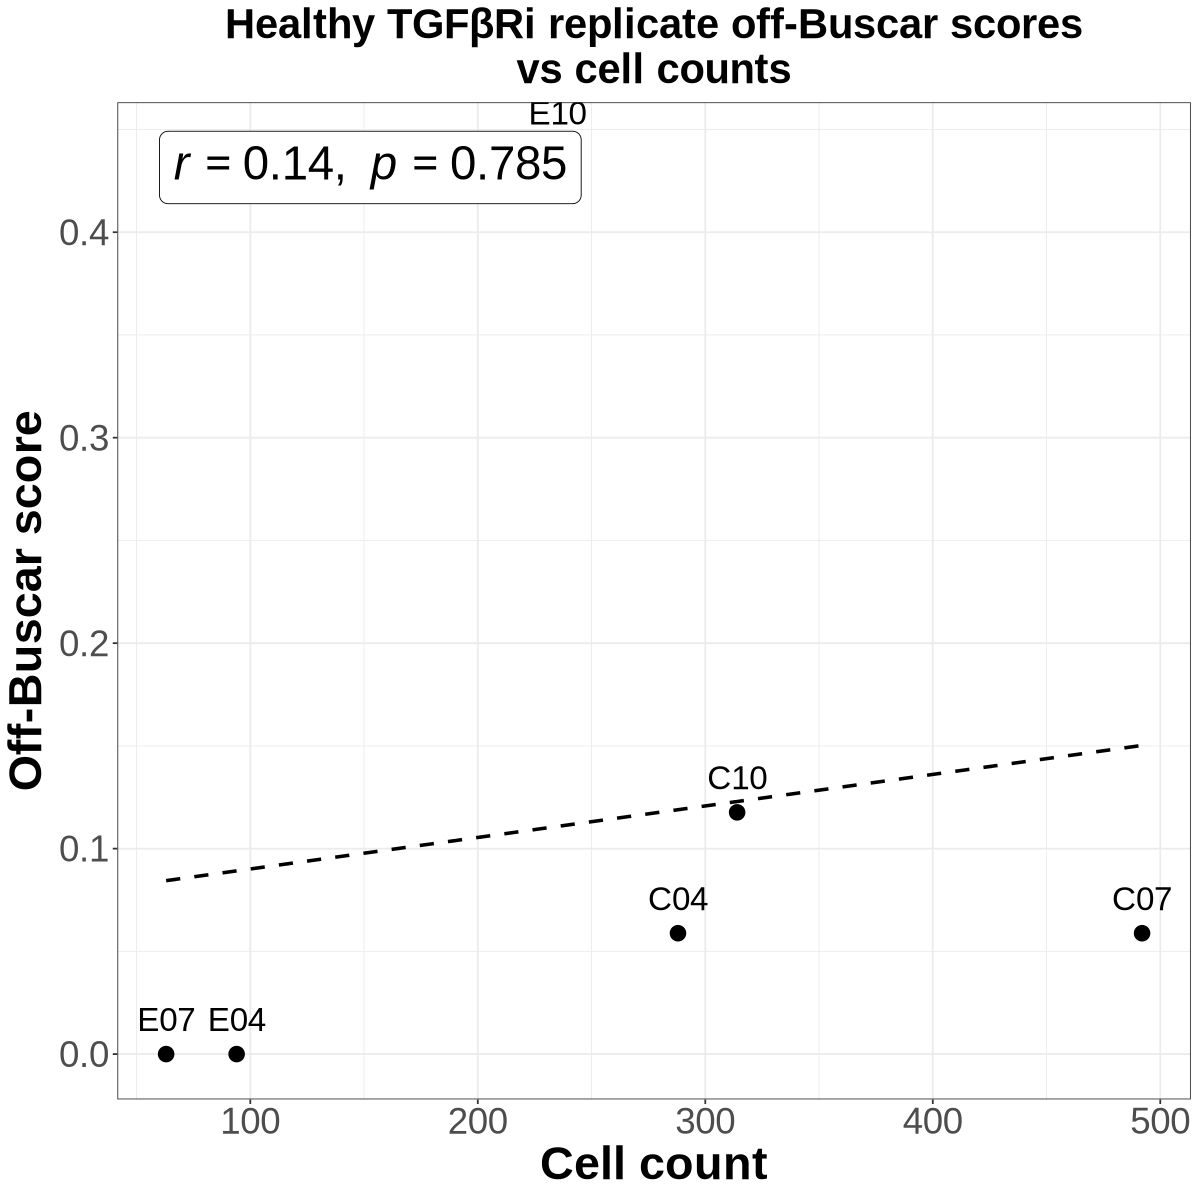

In [3]:
# Filter for failing TGFRi
df_failing <- df %>%
  filter(treatment == "healthy-TGFRi")

# Compute Pearson correlation label with explicit statistical notation
off_cor <- cor.test(df_failing$cell_counts, df_failing$off_buscar_scores, method = "pearson")
off_label <- sprintf(
  "italic(r) == %.2f*','~~italic(p) == %.3f",
  unname(off_cor$estimate),
  off_cor$p.value
)

# Create plot for Off-Buscar score
p_off <- ggplot(df_failing, aes(x = cell_counts, y = off_buscar_scores)) +
  geom_point(size = 4) +
  geom_text(aes(label = well), vjust = -1, size = 7) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linetype = "dashed") +
  annotate(
    "label",
    x = -Inf, y = Inf,
    label = off_label,
    parse = TRUE,
    hjust = -0.1, vjust = 1.4,
    size = 10,
    fill = "white"
  ) +
  labs(
    title = "Healthy TGFβRi replicate off-Buscar scores\nvs cell counts",
    x = "Cell count",
    y = "Off-Buscar score"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 25, face = "bold"),
    axis.title = element_text(size = 28, face = "bold"),
    axis.text = element_text(size = 22),
    legend.position = "none"
  )

# Save plot
ggsave("figures/failing_tgfri_off_buscar_vs_cell_count.png", p_off, width = 10, height = 10, dpi = 300)

p_off